In [ ]:
import pymc as pm
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pytensor as pt

df = pd.read_csv('full_data_bhm1.csv', keep_default_na=False, na_values=[''])
region_unemployment_rates = df.groupby('region')['stateUnemploymentRate'].mean()
df['regionUnemploymentRate'] = df['region'].map(region_unemployment_rates).round(1)
df

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,closedByRegion_2023,totalByState_2024,closedByState_2024,totalByRegion_2024,closedByRegion_2024,totalByState_2025,closedByState_2025,totalByRegion_2025,closedByRegion_2025,regionUnemploymentRate
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,1,69,0,2055,4,69,0,2055,2,3.6
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,4,413,3,1163,8,413,0,1163,0,4.1
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,6,102,1,1323,9,102,0,1323,4,4.1
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,4,144,1,1163,8,144,0,1163,0,4.1
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,4,144,0,1163,8,144,0,1163,0,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Eastern Nazarene College,1900,Massachusetts,MA,Suburb,Large,Private,Nonprofit,4-year,True,...,4,144,1,1163,8,144,0,1163,0,4.1
61,Cox College,1907,Missouri,MO,City,Midsize,Private,Nonprofit,4-year,True,...,6,137,0,1323,9,137,2,1323,4,4.1
62,University of Wisconsin–Platteville Richland,1967,Wisconsin,WI,Town,Distant,Public,Nonprofit,4-year,True,...,6,88,4,1323,9,88,1,1323,4,4.1
63,Maryland University of Integrative Health,1974,Maryland,MD,Suburb,Large,Private,Nonprofit,graduate school,False,...,1,77,0,2055,4,77,1,2055,2,3.6


In [30]:
years = [i for i in range(2020, 2026)]
states = df['state'].unique()
regions = df['region'].unique()

state_data = []
region_data = []
for year in years:
    for state in states:
        state_df_temp = df[df['state'] == state]
        total = state_df_temp[f'totalByState_{year}'].sum()
        closed = state_df_temp[f'closedByState_{year}'].sum()
        if total > 0:
            state_data.append({
                'state': state,
                'year': year,
                'total': total,
                'closed': closed,                
                # 'endowmentMedian': state_df_temp['endowmentMedian'].mean(),
                'stateBirthRate': state_df_temp['stateBirthRate'].mean(),
                'stateUnemploymentRate': state_df_temp['stateUnemploymentRate'].mean(),
                'hasReligionAffiliation': state_df_temp['hasReligionAffiliation'].any(),
                'locationType': state_df_temp['locationType'].mode()[0]
            })
    for region in regions:
        region_df_temp = df[df['region'] == region]
        total = region_df_temp[f'totalByRegion_{year}'].sum()
        closed = region_df_temp[f'closedByRegion_{year}'].sum()
        if total > 0:
            region_data.append({
                'region': region,
                'year': year,
                'total': total,
                'closed': closed,
                # 'endowmentMedian': region_df_temp['endowmentMedian'].mean(),
                'regionBirthRate': region_df_temp['regionBirthRate'].mean(),
                'regionUnemploymentRate': region_df_temp['regionUnemploymentRate'].mean(),
                'hasReligionAffiliation': region_df_temp['hasReligionAffiliation'].any(),
                'locationType': region_df_temp['locationType'].mode()[0]
            })

state_df = pd.DataFrame(state_data)
region_df = pd.DataFrame(region_data)

region_df

,region,year,total,closed,regionBirthRate,regionUnemploymentRate,hasReligionAffiliation,locationType
0,South,2020,24648,0,11.56,3.6,True,City
1,Northeast,2020,19771,34,10.40,4.1,True,Suburb
2,Midwest,2020,34372,104,11.13,4.1,True,City
3,West,2020,12540,0,10.93,5.0,True,City
4,South,2021,24660,48,11.56,3.6,True,City
5,Northeast,2021,19771,34,10.40,4.1,True,Suburb
6,Midwest,2021,34372,26,11.13,4.1,True,City
7,West,2021,12540,20,10.93,5.0,True,City
8,South,2022,24660,12,11.56,3.6,True,City
9,Northeast,2022,19771,17,10.40,4.1,True,Suburb


In [ ]:
location_type_map = {loc: i for i, loc in enumerate(state_df['locationType'].unique())}
location_type_idx = [location_type_map[loc] for loc in state_df['locationType']]

with pt.config.change_flags(exception_verbosity='high'):
    with pm.Model() as model:
        mu_global = pm.Normal('mu_global', mu=0, sigma=10)
        sigma_region = pm.HalfNormal('sigma_region', sigma=5)
        region_effects = pm.Normal('region_effects', mu=0, sigma=sigma_region, shape=len(regions))
        
        region_idx_map = {region: i for i, region in enumerate(regions)}
        state_to_region = dict(zip(df['state'], df['region']))
        state_region_idx = [region_idx_map[state_to_region[state_df.loc[i, 'state']]] for i in range(len(state_df))]
        
        sigma_state = pm.HalfNormal('sigma_state', sigma=5)
        state_effects = pm.Normal('state_effects', mu=region_effects[state_region_idx], sigma=sigma_state, shape=len(state_df))
        
        beta_endowment = pm.Normal('beta_endowment', mu=0, sigma=5)
        beta_birth = pm.Normal('beta_birth', mu=0, sigma=5)
        beta_unemp = pm.Normal('beta_unemp', mu=0, sigma=5)
        beta_religion = pm.Normal('beta_religion', mu=0, sigma=5)
        sigma_loc = pm.HalfNormal('sigma_loc', sigma=2)
        location_effects = pm.Normal('location_effects', mu=0, sigma=sigma_loc, shape=len(location_type_map))
        
        logit_p = (mu_global + 
                  region_effects[state_region_idx] + 
                  state_effects + 
                #   beta_endowment * pm.math.log1pexp(state_df['endowmentMedian']) + 
                  beta_birth * pm.math.log1pexp(state_df['stateBirthRate']) + 
                  beta_unemp * pm.math.log1pexp(state_df['stateUnemploymentRate']) + 
                  beta_religion * state_df['hasReligionAffiliation'].astype(int) + 
                  location_effects[location_type_idx])
        
        p = pm.Deterministic('p', pm.math.sigmoid(logit_p))
        y = pm.Binomial('y', n=state_df['total'], p=p, observed=state_df['closed'])
        
        trace = pm.sample(8000, tune=2000, target_accept=0.9, return_inferencedata=True, random_seed=42, progressbar=True)

az.to_netcdf(trace, 'good_bhm_traces/enhanced_8k_2k_4.nc')

print(f"r_hat > 1.01: {(az.rhat(trace) > 1.01).sum()}")
print(f"ess < 100: {(az.ess(trace) < 100).sum()}")
print(f"ess < 1000: {(az.ess(trace) < 1000).sum()}")
az.summary(trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, sigma_region, region_effects, sigma_state, state_effects, beta_endowment, beta_birth, beta_unemp, beta_religion, sigma_loc, location_effects]


Output()

Sampling 4 chains for 2_000 tune and 8_000 draw iterations (8_000 + 32_000 draws total) took 140 seconds.
There were 77 divergences after tuning. Increase `target_accept` or reparameterize.


r_hat > 1.01: <xarray.Dataset> Size: 96B
Dimensions:           ()
Data variables:
    mu_global         int64 8B 0
    region_effects    int64 8B 0
    state_effects     int64 8B 0
    beta_endowment    int64 8B 0
    beta_birth        int64 8B 0
    beta_unemp        int64 8B 0
    beta_religion     int64 8B 0
    location_effects  int64 8B 0
    sigma_region      int64 8B 0
    sigma_state       int64 8B 0
    sigma_loc         int64 8B 0
    p                 int64 8B 0
ess < 100: <xarray.Dataset> Size: 96B
Dimensions:           ()
Data variables:
    mu_global         int64 8B 0
    region_effects    int64 8B 0
    state_effects     int64 8B 0
    beta_endowment    int64 8B 0
    beta_birth        int64 8B 0
    beta_unemp        int64 8B 0
    beta_religion     int64 8B 0
    location_effects  int64 8B 0
    sigma_region      int64 8B 0
    sigma_state       int64 8B 0
    sigma_loc         int64 8B 0
    p                 int64 8B 0
ess < 1000: <xarray.Dataset> Size: 96B
Dimensio

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,-1.719,3.260,-7.840,4.424,0.066,0.050,2615.0,1776.0,1.00
region_effects[0],-0.203,0.428,-0.887,0.402,0.034,0.124,933.0,292.0,1.01
region_effects[1],-0.113,0.420,-0.746,0.555,0.035,0.125,1024.0,289.0,1.01
region_effects[2],0.133,0.404,-0.384,0.878,0.031,0.110,1017.0,296.0,1.00
region_effects[3],0.040,0.420,-0.579,0.819,0.030,0.105,1021.0,300.0,1.01
...,...,...,...,...,...,...,...,...,...
p[163],0.001,0.002,0.000,0.004,0.000,0.000,25917.0,14265.0,1.00
p[164],0.003,0.007,0.000,0.010,0.000,0.000,36993.0,20223.0,1.00
p[165],0.001,0.002,0.000,0.004,0.000,0.000,30345.0,17152.0,1.00
p[166],0.007,0.008,0.000,0.021,0.000,0.000,50342.0,23319.0,1.00


In [36]:
trace = az.from_netcdf('good_bhm_traces/enhanced_8k_2k_4.nc')
sumary = az.summary(trace, var_names=['mu_global', 'p', 
                                   'beta_endowment', 'beta_birth', 'beta_unemp', 'beta_religion'], 
                                   hdi_prob=0.95)
sumary.to_csv('good_bhm_traces/enhanced_8k_2k_4_summary.csv')

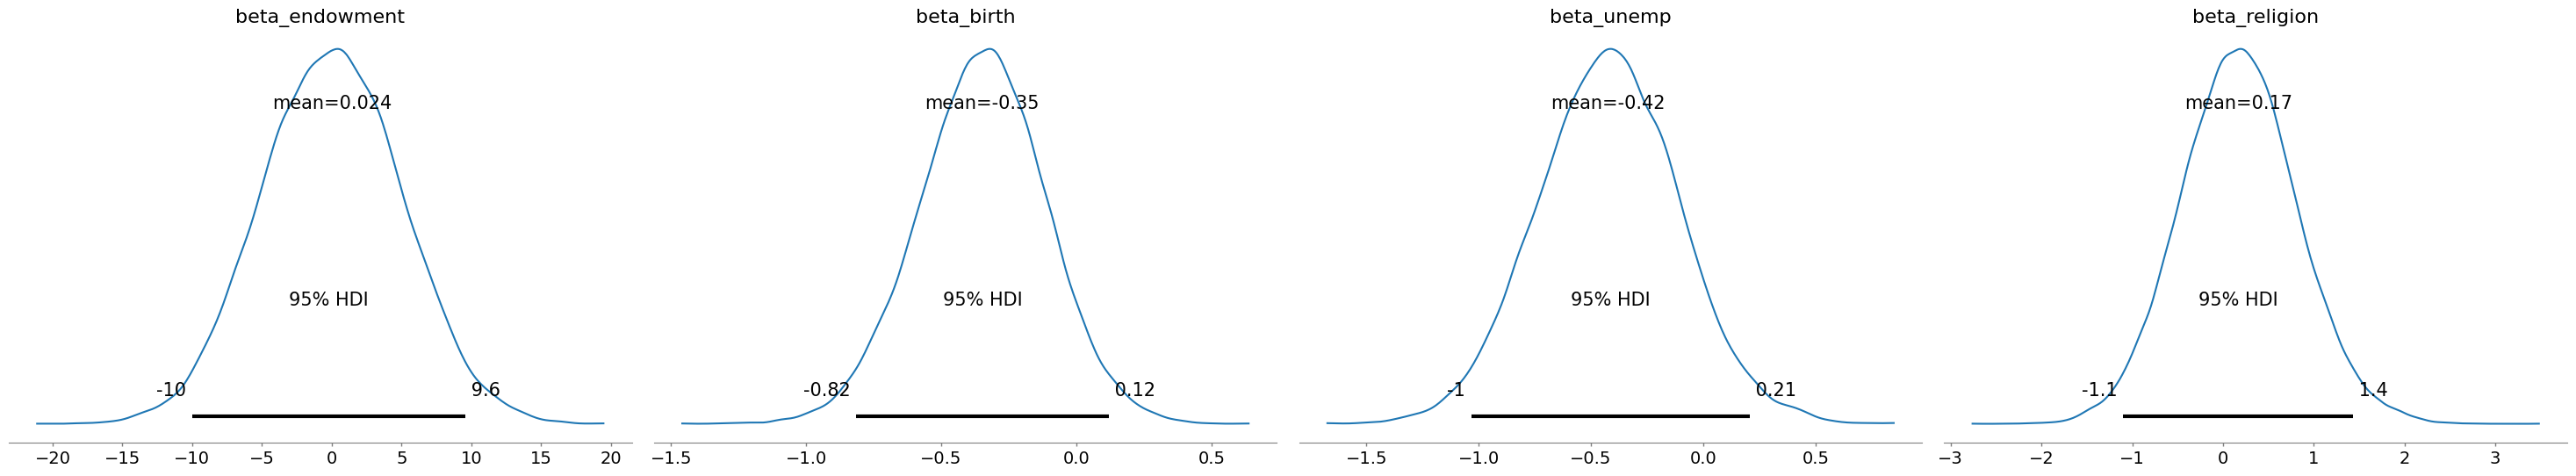

In [35]:
az.plot_posterior(trace, var_names=['beta_endowment', 'beta_birth', 'beta_unemp', 'beta_religion'], hdi_prob=0.95)
plt.tight_layout()
plt.show()